# Imports

In [1]:
import os
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from segment_anything.utils.transforms import ResizeLongestSide
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor


# from segment_anything import SAM


# Setup

In [2]:
# Initialize the SAM model
sam_checkpoint = "C:/Users/imoha/Downloads/sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)  # Ensure the model is on the correct device
mask_generator = SamAutomaticMaskGenerator(sam)

resize_transform = ResizeLongestSide(sam.image_encoder.img_size)

In [3]:
# Helper function to prepare images
def prepare_image(image, transform, device):
    image = transform.apply_image(image)
    image = torch.as_tensor(image, device=device, dtype=torch.float32)
    return image.permute(2, 0, 1).contiguous()

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

# Function to process and show images and masks
def process_and_show(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # image_tensor = prepare_image(image, resize_transform, device)
    
    masks = mask_generator.generate(image)
    
    print(len(masks))
    print(masks[0].keys())
    print(masks[0].get("predicted_iou"))
    
    # Display the image and masks
    plt.figure(figsize=(20,20))
    plt.imshow(image)
    show_anns(masks)
    plt.axis('off')
    plt.show() 

def generate_mask_dictionary(image_directory):
    mask_dictionary = {}
    image_files = os.listdir(image_directory)[:100]
    counter = 1
    for img_file in image_files:
        print(f"Processing image {counter}: {img_file}")
        img_path = os.path.join(image_directory, img_file)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        masks = mask_generator.generate(image)
        mask_dictionary[img_file] = masks
        counter += 1
    return mask_dictionary


def evaluate_iou(mask_dictionary, mask_directory):
    total_iou = 0
    count = 0
    for img_file, predicted_masks in mask_dictionary.items():
        ious = []
        ground_truth_path = os.path.join(mask_directory, img_file.replace('.jpg', '.png'))
        if os.path.exists(ground_truth_path):
            ground_truth_mask = cv2.imread(ground_truth_path, cv2.IMREAD_GRAYSCALE)
            ground_truth_mask = ground_truth_mask > 128  # Convert to binary mask: white (object) is True

            # print(f"\n\n\n\n{ground_truth_mask}")
            for predicted_mask in predicted_masks:
                predicted_segmentation = predicted_mask['segmentation'] > 0  # Assuming mask output needs thresholding
                intersection = np.logical_and(ground_truth_mask, predicted_segmentation).sum()
                # print(f"\n\n\n\n{predicted_segmentation}")
                union = np.logical_or(ground_truth_mask, predicted_segmentation).sum()
                iou = intersection / union if union != 0 else 0
                ious.append(iou)
            count += 1
            # print(f"ious list: {ious}")
            # print(f"ious max: {max(ious)}")
            total_iou += max(ious)
    return total_iou / count if count != 0 else 0


In [4]:
print(device)

cuda


# Process


0
22
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.0149509906768799


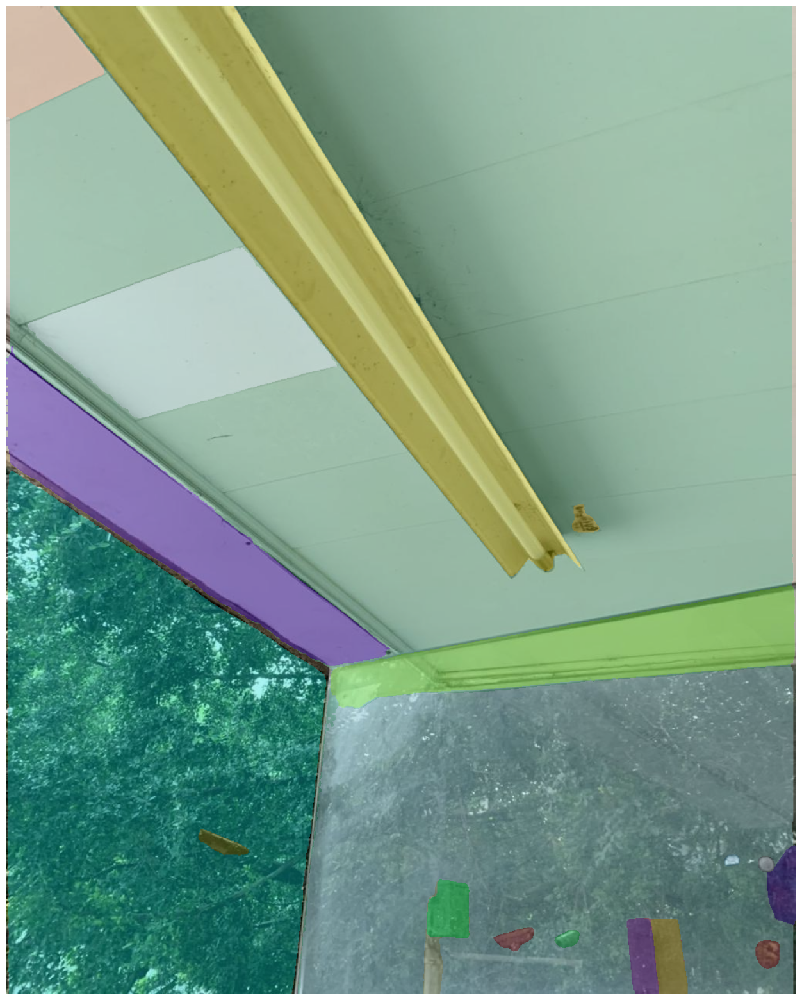


1
64
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.018878698348999


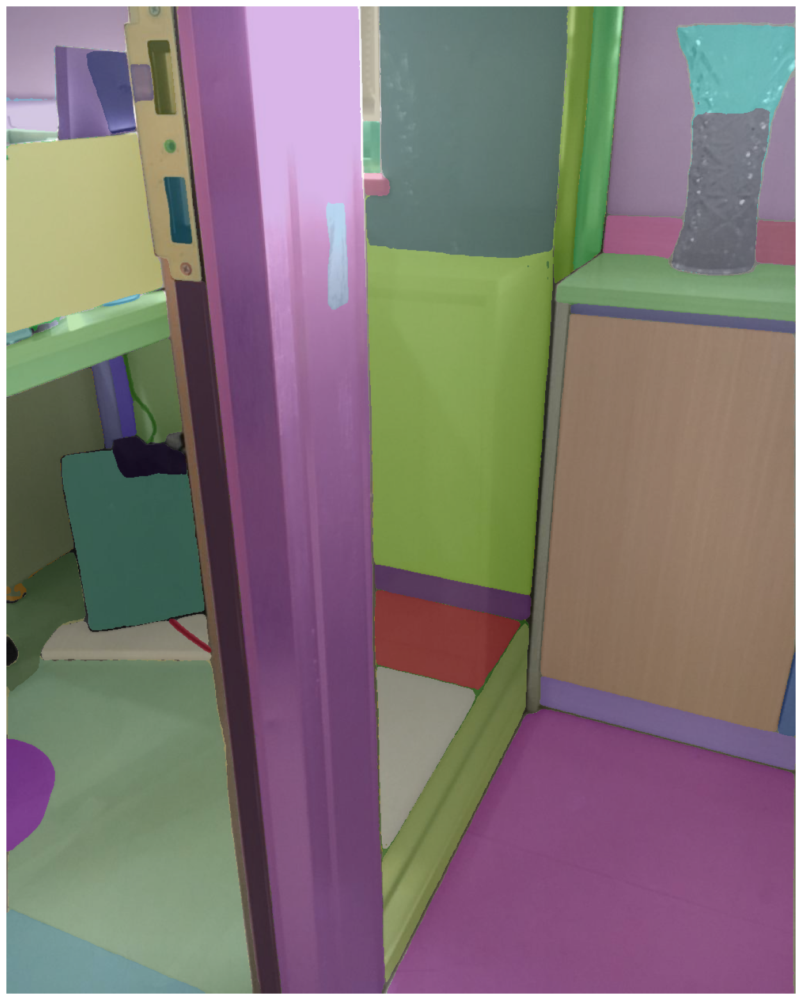


2
44
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.0347704887390137


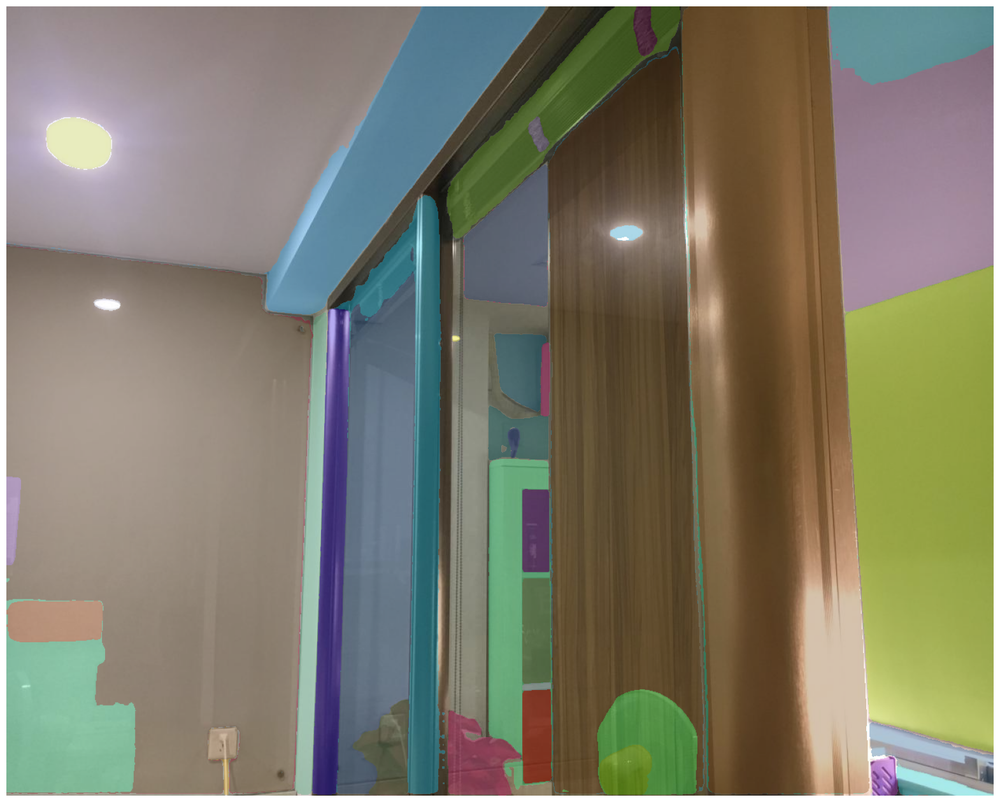


3
81
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.0230640172958374


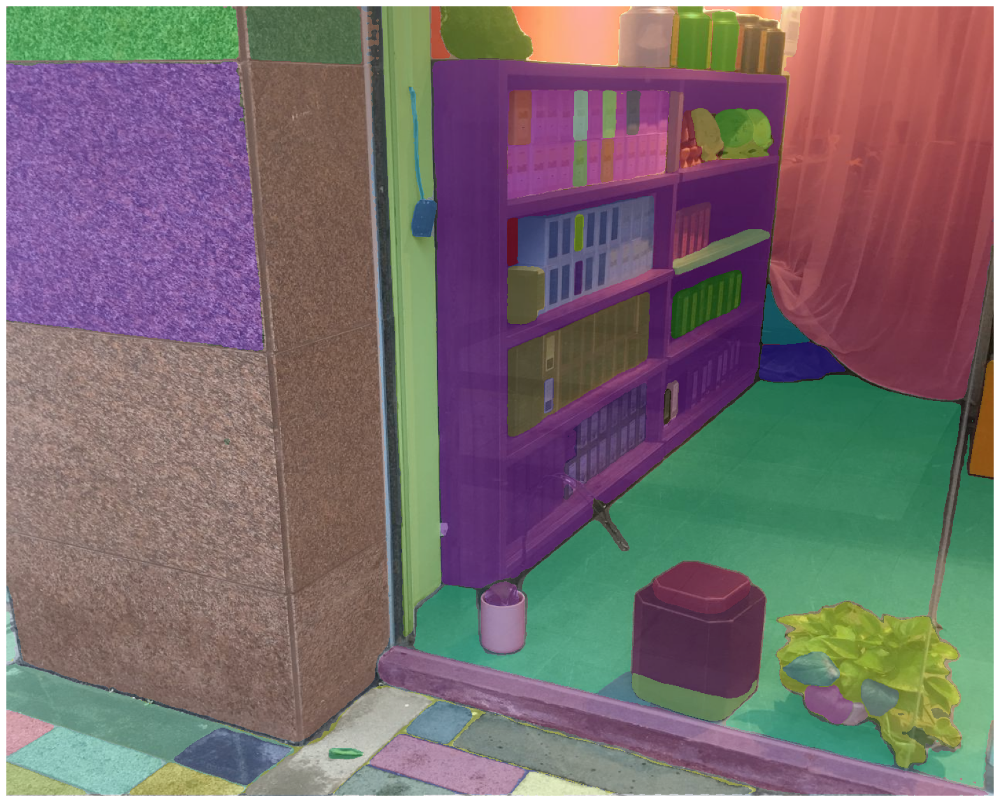


4
54
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.0214869976043701


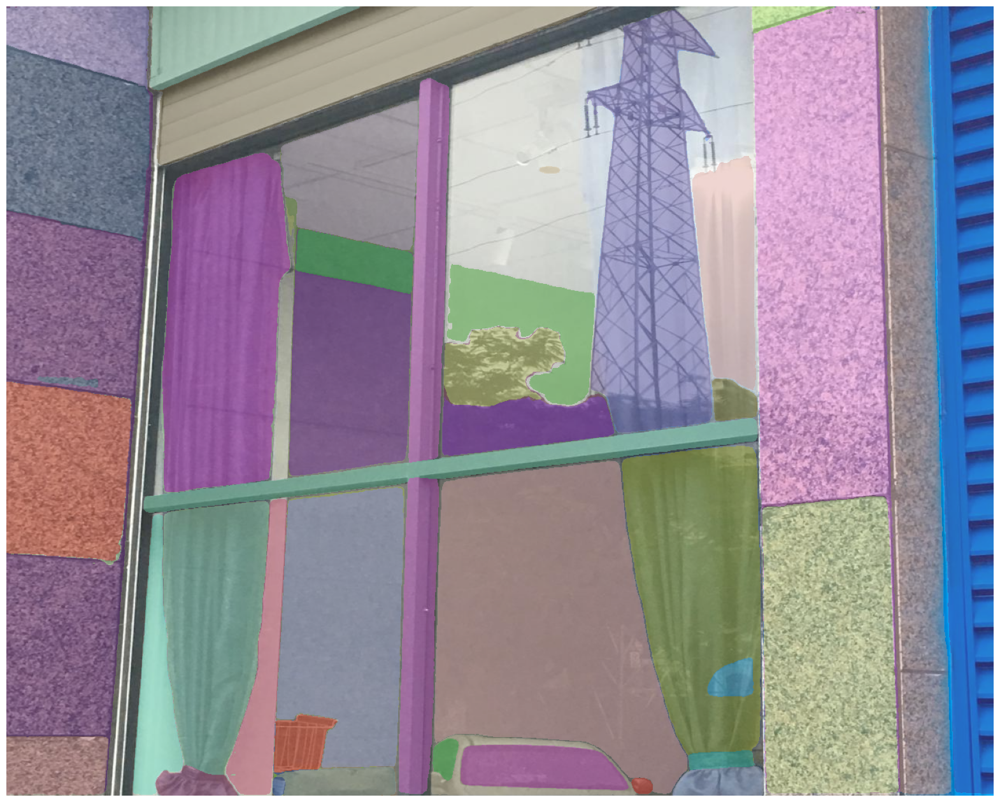


5
44
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.0151312351226807


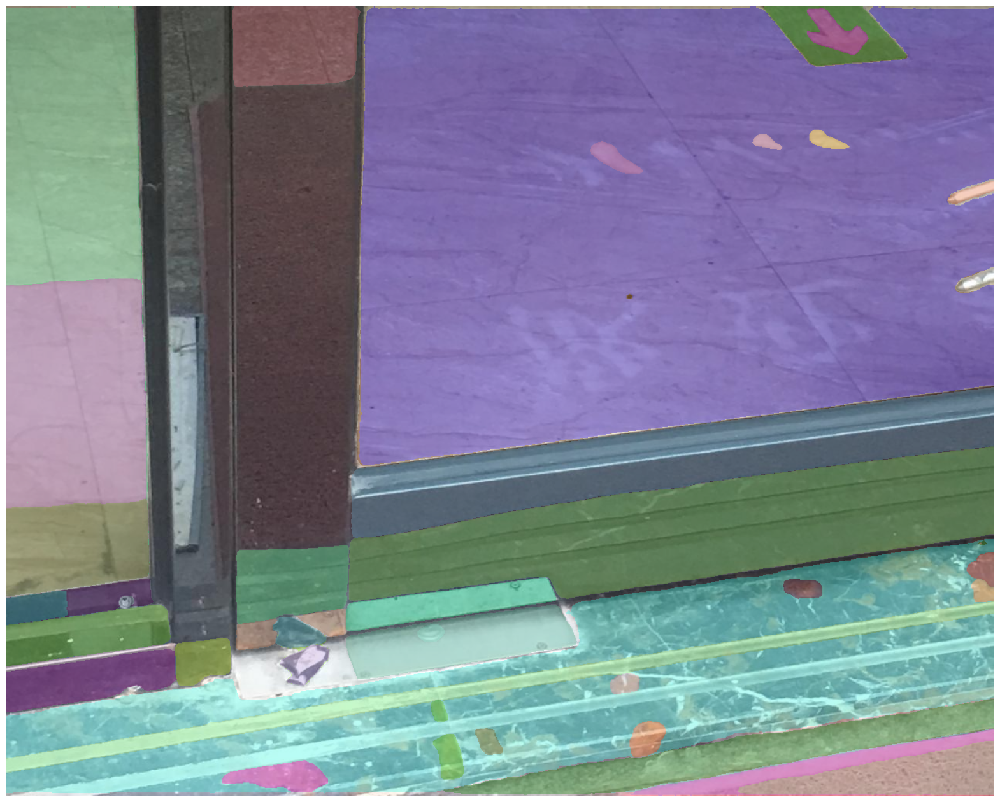


6
44
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.005388617515564


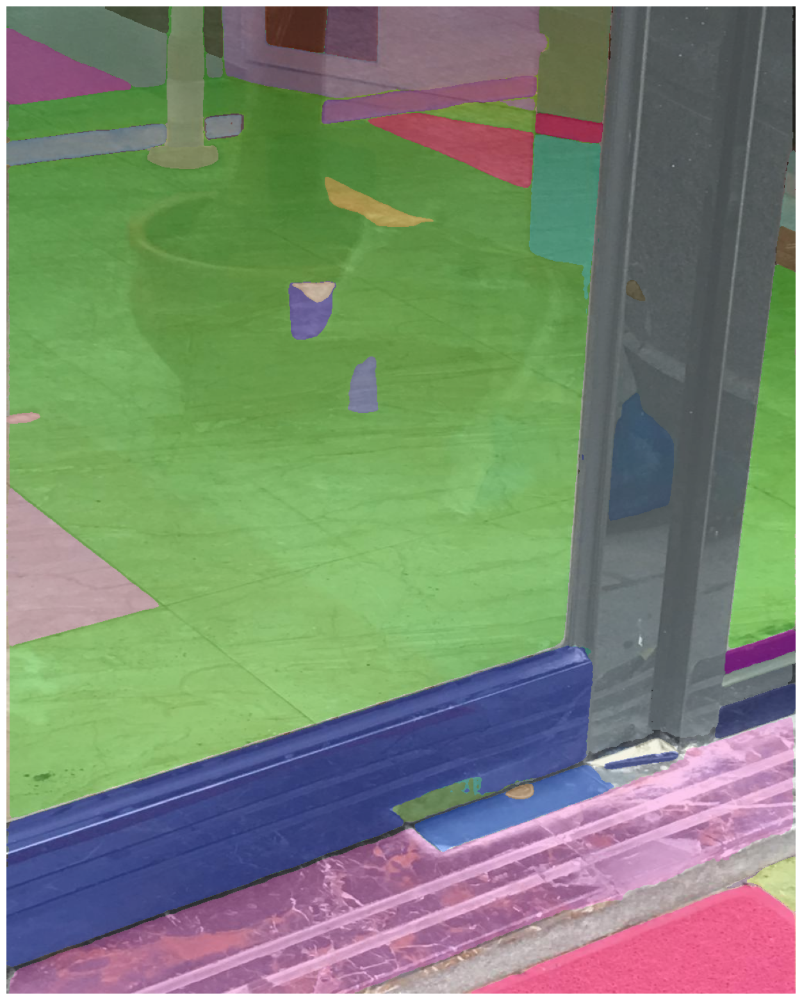


7
48
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
1.060792088508606


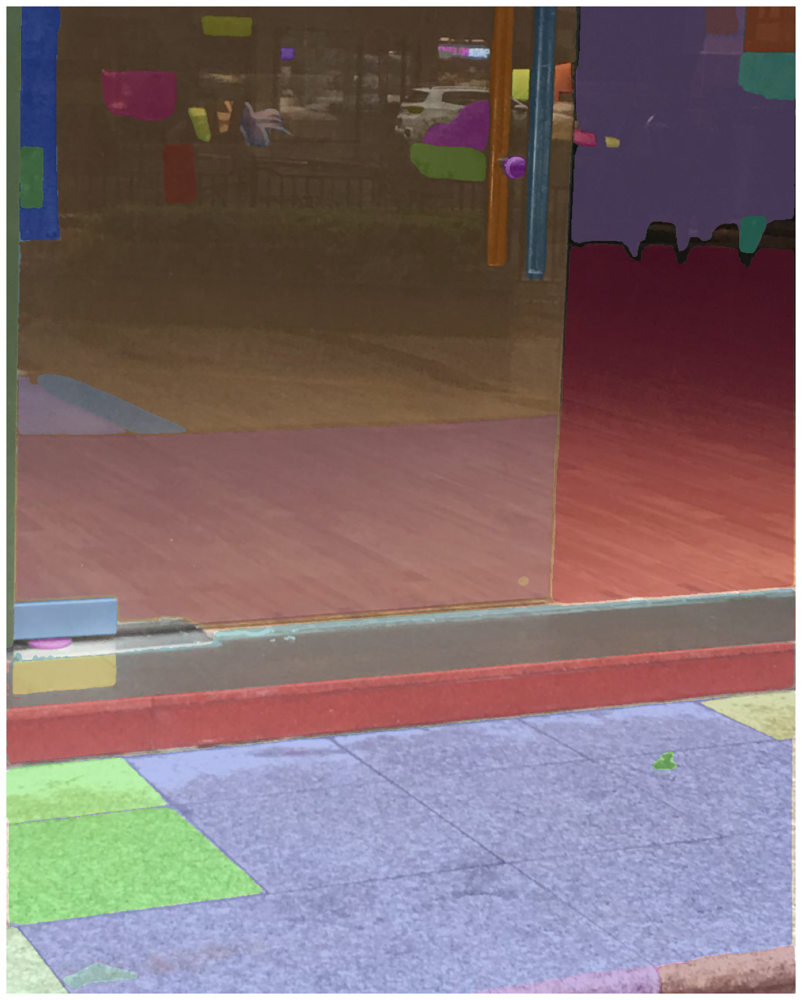

In [5]:
# Directory containing the images
image_directory = 'train/train/image'
mask_directory = 'train/train/mask'
image_files = os.listdir(image_directory)[:8]
count = 0

# Read images from the folder and evaluate
for i, img_file in enumerate(image_files):
    print("\n" + str(count))
    img_path = os.path.join(image_directory, img_file)
    process_and_show(img_path)
    count+=1



In [ ]:
image_directory = 'train/train/image'
mask_directory = 'train/train/mask'
mask_dictionary = generate_mask_dictionary(image_directory)


In [29]:
# print((mask_dictionary["1.jpg"]))

average_iou = evaluate_iou(mask_dictionary, mask_directory)
print("Average IoU:", average_iou)

Average IoU: 0.4512435450788416
